In [1]:
print("Let's Start")

Let's Start


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.shape

(3554, 18)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [6]:
latlong = pd.read_csv('latlong.csv')

In [7]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [8]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [9]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [10]:

latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [11]:
new_df = df.merge(latlong, on='sector')

In [12]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='str')

In [15]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3329 entries, 0 to 3328
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3329 non-null   str    
 1   society          3329 non-null   str    
 2   sector           3329 non-null   str    
 3   price            3329 non-null   float64
 4   price_per_sqft   3329 non-null   float64
 5   bedRoom          3329 non-null   float64
 6   bathroom         3329 non-null   float64
 7   balcony          3329 non-null   str    
 8   floorNum         3329 non-null   float64
 9   agePossession    3329 non-null   str    
 10  built_up_area    3329 non-null   float64
 11  study room       3329 non-null   float64
 12  servant room     3329 non-null   float64
 13  store room       3329 non-null   float64
 14  pooja room       3329 non-null   float64
 15  others           3329 non-null   float64
 16  furnishing_type  3329 non-null   float64
 17  luxury_score     3329 non

In [16]:
group_df = (
    new_df.groupby('sector')[[
        'price',
        'price_per_sqft',
        'built_up_area',
        'latitude',
        'longitude'
    ]]
    .mean()
)

In [17]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
...,...,...,...,...,...
sector 91,1.648235,7586.117647,2028.647059,28.4014,76.9225
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326


In [22]:
print(group_df[['latitude', 'longitude']].head())
print(group_df[['latitude', 'longitude']].dtypes)

print("Latitude range:", group_df['latitude'].min(), group_df['latitude'].max())
print("Longitude range:", group_df['longitude'].min(), group_df['longitude'].max())

print("Rows:", len(group_df))

             latitude  longitude
sector                          
gwal pahari   28.4484    77.0210
manesar       28.3515    76.9428
sector 1      28.3663    76.9456
sector 10     28.4537    77.0009
sector 102    28.4750    76.9715
latitude     float64
longitude    float64
dtype: object
Latitude range: 28.3515 28.528700000000004
Longitude range: 76.897 77.1105
Rows: 101


In [23]:
group_df['latitude'] = pd.to_numeric(group_df['latitude'], errors='coerce')
group_df['longitude'] = pd.to_numeric(group_df['longitude'], errors='coerce')

group_df = group_df.dropna(subset=['latitude', 'longitude'])

In [25]:
import plotly.express as px

fig = px.scatter_map(
    group_df,
    lat="latitude",
    lon="longitude",
    color="price_per_sqft",
    size="built_up_area",
    color_continuous_scale=px.colors.cyclical.IceFire,
    zoom=10,
    map_style="open-street-map",
    center={
        "lat": group_df["latitude"].mean(),
        "lon": group_df["longitude"].mean()
    },
    text=group_df.index
)

fig.show()

In [26]:
new_df.to_csv('data_viz1.csv',index=False)

In [27]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [28]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sector 59 Gurgaon,flat,mahindra luminare,5.50,18181.0,3025.0,Super Built up area 3025(281.03 sq.m.),3,3,1,servant room,"Sector 59 Gurgaon, Gurgaon, Haryana",26.0,NaN,Dec 2024,"['Sector 55-56 Metro Station', 'Metro World Ma...",Located in the popular residential address of ...,"['4 Fan', '4 Light', '4 AC', '1 Modular Kitche...","['Lift(s)', 'Swimming Pool', 'Park', 'Fitness ...","['Green Area5 out of 5', 'Construction5 out of..."
1,3 BHK Flat in Sector-33 Sohna,flat,central park flower valley,1.79,11251.0,1591.0,Super Built up area 1789(166.2 sq.m.),3,3,3,NaN,"B Tower, Sector-33 Sohna, Gurgaon, Haryana",3.0,South,10+ Year Old,"['Golf Course Extension Rd', 'Rajiv Chowk - So...",Aqua facing unit luxury unit ! Parking all inc...,"['3 Wardrobe', '4 AC', '1 Modular Kitchen', 'N...","['Feng Shui / Vaastu Compliant', 'Lift(s)', 'H...",NaN
2,3 Bedroom House for sale in Rosewood,house,independent,2.95,16388.0,1800.0,Plot area 1800(167.23 sq.m.)Built Up area: 190...,3,3,3,store room,3 Bhk With 3 Bath Independent Villa For Sale A...,2.0,North-West,5 to 10 Year Old,"['Sri Radhe Krishna Temple', 'Standard charter...",Well maintained owner self living 3 bhk with 3...,"['3 Wardrobe', '1 Water Purifier', '6 Fan', '1...","['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Safety5 out of 5', ..."
3,4 Bedroom House for sale in DLF Phase 2,house,dlf city plots phase 2,6.30,35000.0,1800.0,Plot area 200(167.23 sq.m.),4,4,3+,"servant room,store room","Dlf Phase 2, DLF Phase 2, Gurgaon, Haryana",2.0,East,10+ Year Old,"['Sahara Mall', 'Delhi Public School', 'Privat...",This is a four bedroom house in dlf phase - 2 ...,NaN,"['Feng Shui / Vaastu Compliant', 'Private Gard...","['Environment5 out of 5', 'Safety5 out of 5', ..."
4,4 Bedroom House for sale in Arjun Nagar,house,independent,0.82,10224.0,802.0,Carpet area: 802 (74.51 sq.m.),4,4,0,NaN,"Arjun Nagar, Gurgaon, Haryana, India, Arjun Na...",2.0,NaN,undefined,"['Lal Superspeciality Hospital', 'Shri Gobind ...",An independant 2 storey well maintained house ...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Environment4 out of 5', 'Lifestyle4 out of 5..."


In [29]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [30]:
wordcloud_df.head()

,features,sector
0,"['Lift(s)', 'Swimming Pool', 'Park', 'Fitness ...",sector 36
1,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'H...",sector 89
2,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sohna road
3,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 92
4,NaN,sector 102


In [31]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [32]:
main

['Lift(s)',
 'Swimming Pool',
 'Park',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Feng Shui / Vaastu Compliant',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'Piped-gas',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Club house / Community Center',
 'Water softening plant',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'Bank Attached Property',
 'Visitor Parking',
 'Park',
 'Security Personnel',
 'Low Density Society',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Bank Attached Property',
 'Visitor Parking',
 'Park',
 'Security Personnel',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density

In [34]:
%pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.3/546.3 kB 217.1 kB/s  0:00:02m-:--:--
Note: you may need to restart the kernel to use updated packages.


In [35]:
from wordcloud import WordCloud

In [36]:
feature_text = ' '.join(main)

In [37]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [38]:
feature_text

'Lift(s) Swimming Pool Park Fitness Centre / GYM Club house / Community Center Feng Shui / Vaastu Compliant Lift(s) High Ceiling Height Maintenance Staff Water Storage Piped-gas Visitor Parking Swimming Pool Park Shopping Centre Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Water softening plant Feng Shui / Vaastu Compliant Private Garden / Terrace High Ceiling Height Maintenance Staff Water Storage Bank Attached Property Visitor Parking Park Security Personnel Low Density Society Fitness Centre / GYM Waste Disposal Rain Water Harvesting Feng Shui / Vaastu Compliant Private Garden / Terrace High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Bank Attached Property Visitor Parking Park Security Personnel Airy Rooms Spacious Interiors Low Density Society Feng Shui / Vaastu Compliant Private Garden / Terrace False Ceiling Lighting Water Storage No open drainage around Recently Renovated Piped-gas Visitor Parking Park Natural

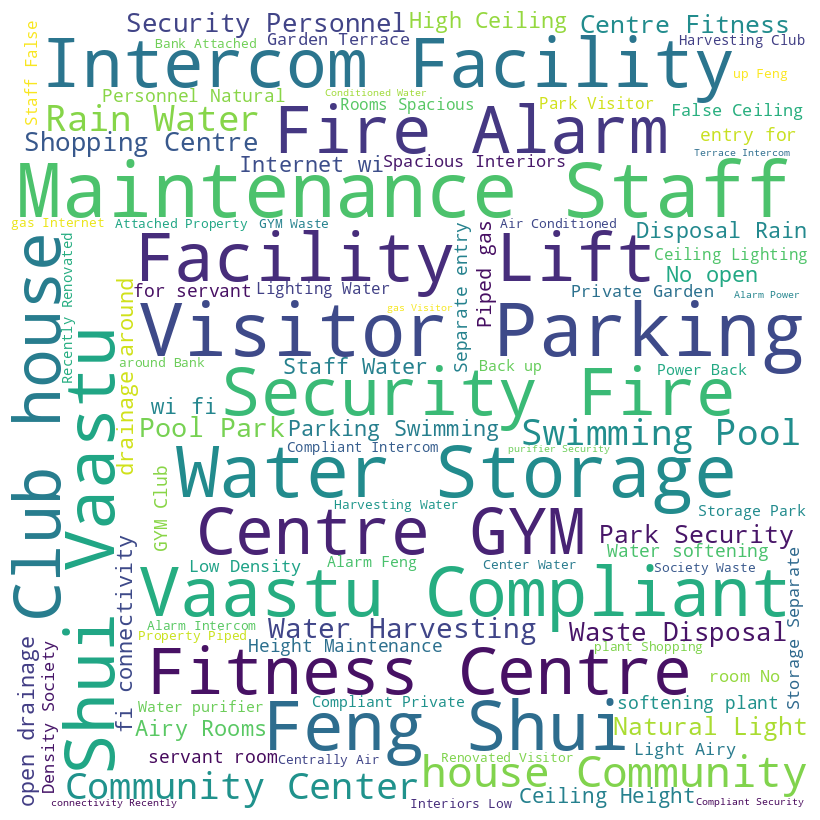

In [39]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [40]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [41]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [42]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [43]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


/tmp/ipykernel_33128/3761596323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == 'house']['price'])
/tmp/ipykernel_33128/3761596323.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == 'flat']['price'])


<Axes: xlabel='price', ylabel='Density'>

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

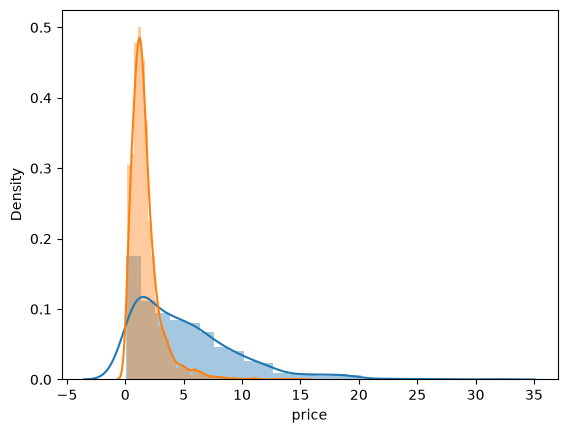

In [44]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [45]:
new_df['sector'].unique().tolist().insert(0,'overall')